<center>

# **Neural Networks & Backpropagation: From Perceptrons to Multi-Layer Networks**

*Deriving the backpropagation algorithm from the chain rule, implementing a multi-layer perceptron from scratch with NumPy, then scaling up with PyTorch on Fashion-MNIST*

<br>
</center>

## **Table of Contents**

1. [Introduction](#Introduction) — From biological neurons to computational graphs
2. [Mathematical Foundation](#Mathematical-Foundation) — Perceptron, activation functions, universal approximation
   - [The Perceptron](#The-Perceptron)
   - [Activation Functions](#Activation-Functions)
   - [Forward Propagation](#Forward-Propagation)
   - [Backpropagation Derivation](#Backpropagation-Derivation)
3. [Optimization](#Optimization) — SGD, momentum, Adam
4. [Regularization & Practical Considerations](#Regularization-&-Practical-Considerations)
5. [Data](#Data) — Fashion-MNIST: loading, EDA, preprocessing
6. [From-Scratch Implementation](#From-Scratch-Implementation) — NumPy MLP with full backprop
7. [PyTorch Implementation](#PyTorch-Implementation) — Modern deep learning framework
8. [Experiments & Results](#Experiments-&-Results) — Architecture, activations, optimizers
9. [Analysis & Conclusion](#Analysis-&-Conclusion) — Key observations, limitations, takeaways, references

## **Introduction**

**Neural networks** are function approximators built by composing layers of simple units (neurons). Each neuron computes a weighted sum of its inputs, adds a bias, and passes the result through a nonlinear **activation function**. Despite their simplicity, stacking these units creates models capable of learning extraordinarily complex mappings.

### **Why Study Neural Networks in Depth?**

Neural networks are the foundation of modern deep learning, and understanding them from first principles is essential for grasping everything that follows. The **Universal Approximation Theorem** (Cybenko, 1989; Hornik, 1991) guarantees that a single hidden layer with sufficient neurons can approximate any continuous function on a compact set, while two or more hidden layers can approximate any measurable function. This theoretical result explains why neural networks are such powerful and flexible models.

The key algorithm that makes training possible is **backpropagation** (Rumelhart, Hinton & Williams, 1986), which applies the chain rule to computational graphs, enabling efficient gradient computation in $O(\text{parameters})$ per training example. Every modern architecture, from CNNs and RNNs to Transformers, is built on the MLP primitives we derive here, making this notebook the gateway to all subsequent deep learning topics.

### **Problem: Fashion-MNIST Classification**

We classify **Fashion-MNIST** (Xiao et al., 2017): 70,000 grayscale 28×28 images of clothing items in 10 categories (T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot). It's a drop-in replacement for MNIST that's harder and more representative of real vision tasks.

## **Mathematical Foundation**

### **The Perceptron**

A single neuron computes:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad a = \sigma(z)$$

where $\mathbf{x} \in \mathbb{R}^d$ is the input, $\mathbf{w} \in \mathbb{R}^d$ the weights, $b$ the bias, and $\sigma$ the activation function.

### **Activation Functions**

Without nonlinear activations, composing layers produces only linear functions (since $W_2(W_1 \mathbf{x} + b_1) + b_2 = W_2 W_1 \mathbf{x} + W_2 b_1 + b_2$). The activation function breaks this linearity.

| Activation | $\sigma(z)$ | $\sigma'(z)$ | Properties |
|------------|------------|-------------|------------|
| Sigmoid | $\frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ | Output in (0,1); saturates → vanishing gradients |
| Tanh | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - \tanh^2(z)$ | Zero-centered; still saturates |
| **ReLU** | $\max(0, z)$ | $\begin{cases}1 & z>0 \\ 0 & z \leq 0\end{cases}$ | No saturation; sparse; dead neurons |
| Leaky ReLU | $\max(\alpha z, z)$ | $\begin{cases}1 & z>0 \\ \alpha & z \leq 0\end{cases}$ | Fixes dead neurons ($\alpha$≈0.01) |

**ReLU** is the default choice for hidden layers due to its simplicity and resistance to vanishing gradients.

*Conceptual illustration: a single perceptron (left) showing inputs, weights, summation, and activation, and a multi-layer perceptron architecture (right) with fully connected layers.*

![From Perceptron to MLP](illustrations/fig1_perceptron_to_mlp.png?v=1)

### **Forward Propagation**

For a network with $L$ layers, forward propagation computes:

$$\mathbf{z}^{[l]} = \mathbf{W}^{[l]} \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}, \qquad \mathbf{a}^{[l]} = \sigma^{[l]}(\mathbf{z}^{[l]})$$

where $\mathbf{a}^{[0]} = \mathbf{x}$ (input), and the output layer uses **softmax** for classification:

$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

The loss function is the **cross-entropy**:

$$\mathcal{L} = -\sum_{k=1}^{K} y_k \log \hat{y}_k$$

where $\mathbf{y}$ is one-hot encoded.

### **Backpropagation Derivation**

Backpropagation computes $\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[l]}}$ and $\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}}$ for all layers using the **chain rule**.

**Output layer** (softmax + cross-entropy, where the derivatives combine beautifully):

$$\boldsymbol{\delta}^{[L]} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{[L]}} = \hat{\mathbf{y}} - \mathbf{y}$$

*Proof*: For softmax output $\hat{y}_k = \text{softmax}(\mathbf{z})_k$ and cross-entropy loss:

$$\frac{\partial \mathcal{L}}{\partial z_k} = -\sum_j y_j \frac{\partial \log \hat{y}_j}{\partial z_k} = -\sum_j y_j \left(\mathbb{1}_{j=k} - \hat{y}_k\right) = \hat{y}_k \underbrace{\sum_j y_j}_{=1} - y_k = \hat{y}_k - y_k$$

**Hidden layers** (recursive application of chain rule):

$$\boldsymbol{\delta}^{[l]} = (\mathbf{W}^{[l+1]\top} \boldsymbol{\delta}^{[l+1]}) \odot \sigma'^{[l]}(\mathbf{z}^{[l]})$$

where $\odot$ is element-wise multiplication.

**Derivation: why does $\mathbf{W}^{[l+1]\top}$ appear?**

Consider a single neuron $j$ in hidden layer $l$. Its pre-activation $z_j^{[l]}$ affects the loss only through the neurons in the *next* layer $l{+}1$. The dependency chain is:

$$z_j^{[l]} \;\longrightarrow\; a_j^{[l]} = \sigma(z_j^{[l]}) \;\longrightarrow\; z_k^{[l+1]} = \sum_j W_{kj}^{[l+1]} a_j^{[l]} + b_k^{[l+1]} \quad \text{for all } k$$

Applying the chain rule to compute $\delta_j^{[l]} = \frac{\partial \mathcal{L}}{\partial z_j^{[l]}}$, we sum over all neurons $k$ in layer $l{+}1$ that $a_j^{[l]}$ feeds into:

$$\delta_j^{[l]} = \frac{\partial \mathcal{L}}{\partial z_j^{[l]}} = \sum_k \underbrace{\frac{\partial \mathcal{L}}{\partial z_k^{[l+1]}}}_{\delta_k^{[l+1]}} \cdot \underbrace{\frac{\partial z_k^{[l+1]}}{\partial a_j^{[l]}}}_{W_{kj}^{[l+1]}} \cdot \underbrace{\frac{\partial a_j^{[l]}}{\partial z_j^{[l]}}}_{\sigma'(z_j^{[l]})}$$

Since $\sigma'(z_j^{[l]})$ does not depend on the index $k$, we factor it out:

$$\delta_j^{[l]} = \sigma'(z_j^{[l]}) \sum_k W_{kj}^{[l+1]} \,\delta_k^{[l+1]}$$

The sum $\sum_k W_{kj}^{[l+1]} \delta_k^{[l+1]}$ is the $j$-th element of the matrix-vector product $\mathbf{W}^{[l+1]\top} \boldsymbol{\delta}^{[l+1]}$, since we are summing over the *row* index $k$ of $\mathbf{W}^{[l+1]}$ with column index $j$ fixed (this is exactly what the transpose does). Stacking all neurons $j$ into a vector:

$$\boxed{\boldsymbol{\delta}^{[l]} = \left(\mathbf{W}^{[l+1]\top} \boldsymbol{\delta}^{[l+1]}\right) \odot \sigma'(\mathbf{z}^{[l]})}$$

> **Intuition.** In the forward pass, $\mathbf{W}^{[l+1]}$ maps activations from layer $l$ to pre-activations in layer $l{+}1$. In the backward pass, $\mathbf{W}^{[l+1]\top}$ does the reverse: it distributes error signals from layer $l{+}1$ back to layer $l$. The element-wise $\sigma'(\mathbf{z}^{[l]})$ then scales each error by how sensitive the activation was to its input.

**Parameter gradients.** Once we have $\boldsymbol{\delta}^{[l]}$ for every layer, the gradients w.r.t. the parameters follow directly:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[l]}} = \boldsymbol{\delta}^{[l]} \mathbf{a}^{[l-1]\top}, \qquad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[l]}} = \boldsymbol{\delta}^{[l]}$$

The weight gradient is an outer product: each element $\frac{\partial \mathcal{L}}{\partial W_{jk}^{[l]}} = \delta_j^{[l]} \cdot a_k^{[l-1]}$, connecting the error at neuron $j$ with the activation that fed into it from neuron $k$.

For a mini-batch of size $B$, we average: $\nabla_{\mathbf{W}^{[l]}} = \frac{1}{B} \sum_{i=1}^{B} \boldsymbol{\delta}^{[l](i)} \mathbf{a}^{[l-1](i)\top}$

**Computational complexity**: $O(\sum_l n_l \cdot n_{l-1})$ per sample, linear in the number of parameters.

*Conceptual illustration: the computational graph shows how each variable depends on the previous one. Green arrows (top) trace the forward computation; coral arrows (bottom) show the local gradients that backpropagation multiplies together via the chain rule.*

![Backpropagation Computational Graph](illustrations/fig2_backprop_flow.png?v=6)

## **Optimization**

### **SGD with Momentum**

Plain SGD: $\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$

With momentum ($\beta$ typically 0.9):

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + (1-\beta) \nabla_\theta \mathcal{L}$$
$$\theta \leftarrow \theta - \eta \mathbf{v}_t$$

Momentum accumulates gradients in consistent directions, accelerating convergence through flat regions and smoothing oscillations.

### **Adam (Adaptive Moment Estimation)**

Adam (Kingma & Ba, 2014) combines momentum with per-parameter adaptive learning rates:

$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1) \mathbf{g}_t \quad \text{(first moment)}$$
$$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2) \mathbf{g}_t^2 \quad \text{(second moment)}$$

Bias correction: $\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1-\beta_1^t}, \quad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1-\beta_2^t}$

Update: $\theta \leftarrow \theta - \eta \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}$

Default hyperparameters: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.

**Why bias correction is needed.** Since $\mathbf{m}_0 = \mathbf{0}$, unrolling the recursion gives:

$$\mathbf{m}_t = (1 - \beta_1) \sum_{i=1}^{t} \beta_1^{t-i} \mathbf{g}_i$$

Taking expectations (assuming stationary gradients $E[\mathbf{g}_i] = E[\mathbf{g}]$):

$$E[\mathbf{m}_t] = (1 - \beta_1) E[\mathbf{g}] \sum_{i=1}^{t} \beta_1^{t-i} = (1 - \beta_1) E[\mathbf{g}] \cdot \frac{1 - \beta_1^t}{1 - \beta_1} = (1 - \beta_1^t)\, E[\mathbf{g}]$$

So $\mathbf{m}_t$ is a biased estimate of the true mean gradient, underestimating it by a factor of $(1 - \beta_1^t)$. Dividing by this factor yields the unbiased estimator $\hat{\mathbf{m}}_t = \mathbf{m}_t / (1 - \beta_1^t)$. The same argument applies to $\mathbf{v}_t$. The bias is most severe during the first few steps (when $\beta_1^t \approx 1$) and vanishes as $t \to \infty$.

*Conceptual illustration: optimizer trajectories on an elongated loss surface, comparing plain SGD (oscillates), SGD with momentum (smoother path), and Adam (adaptive, fastest convergence).*

![Optimizer Trajectories](illustrations/fig3_optimizer_trajectories.png?v=1)

## **Regularization & Practical Considerations**

### **Weight Initialization**

Proper initialization prevents vanishing/exploding gradients:

- **Xavier/Glorot** (for sigmoid/tanh): $W \sim \mathcal{N}(0, \frac{2}{n_{\text{in}} + n_{\text{out}}})$
- **He** (for ReLU): $W \sim \mathcal{N}(0, \frac{2}{n_{\text{in}}})$ — accounts for ReLU killing half the inputs

**Deriving He initialization.** Consider a single layer $z^{[l]} = \mathbf{W}^{[l]} \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}$. Assuming weights and activations are independent with zero mean:

$$\text{Var}(z_j^{[l]}) = n_{\text{in}} \cdot \text{Var}(W_{jk}^{[l]}) \cdot E\!\left[(a_k^{[l-1]})^2\right]$$

For ReLU activations, half the pre-activations are zeroed out, so $E[a^2] = \frac{1}{2} E[z^2] = \frac{1}{2}\text{Var}(z^{[l-1]})$ (assuming zero mean). Requiring the variance to be stable across layers ($\text{Var}(z^{[l]}) = \text{Var}(z^{[l-1]})$):

$$\text{Var}(z^{[l]}) = n_{\text{in}} \cdot \text{Var}(W) \cdot \tfrac{1}{2}\,\text{Var}(z^{[l-1]}) \;\stackrel{!}{=}\; \text{Var}(z^{[l-1]}) \implies \text{Var}(W) = \frac{2}{n_{\text{in}}}$$

### **Dropout**

Randomly zero out neurons with probability $p$ during training (Srivastava et al., 2014). This prevents co-adaptation and acts as an ensemble of $2^n$ sub-networks.

### **Batch Normalization**

Normalize activations within each mini-batch: $\hat{z} = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$, then scale and shift: $\tilde{z} = \gamma \hat{z} + \beta$ (learnable). Reduces internal covariate shift and allows higher learning rates.

## **Data**

### **Fashion-MNIST**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import random

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Load Fashion-MNIST
from torchvision import datasets

fmnist_train = datasets.FashionMNIST(root="./data", train=True, download=True)
fmnist_test = datasets.FashionMNIST(root="./data", train=False, download=True)

X_train = fmnist_train.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = fmnist_train.targets.numpy()
X_test = fmnist_test.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = fmnist_test.targets.numpy()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {class_names}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

100.0%
100.0%
100.0%
100.0%


Training: (60000, 784), Test: (10000, 784)
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Pixel range: [0.0, 1.0]


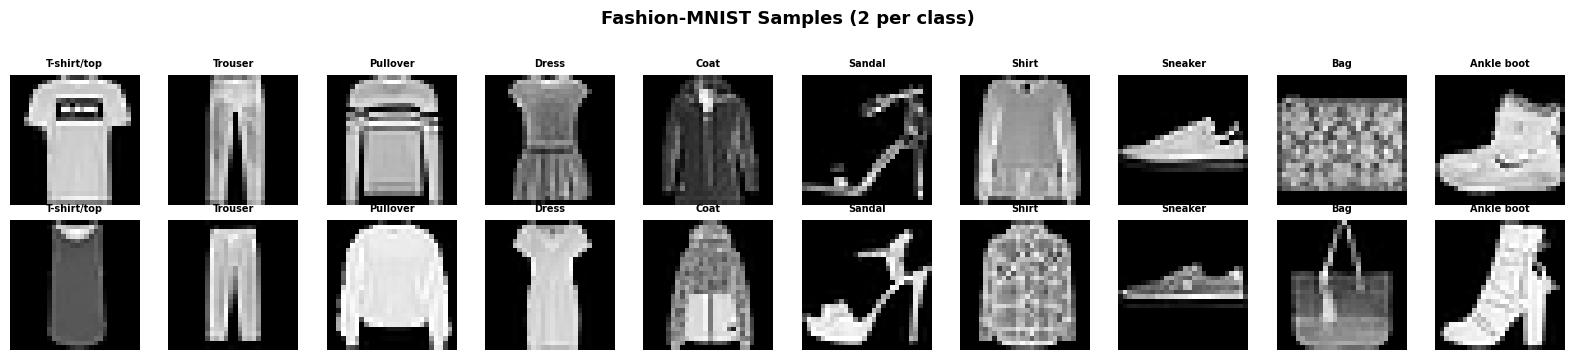

In [3]:
# Sample images
fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
for i in range(10):
    class_idx = np.where(y_train == i)[0]
    for row in range(2):
        idx = class_idx[row]
        axes[row, i].imshow(X_train[idx].reshape(28, 28), cmap="gray")
        axes[row, i].set_title(class_names[i], fontsize=7, fontweight="bold")
        axes[row, i].axis("off")
plt.suptitle("Fashion-MNIST Samples (2 per class)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## **From-Scratch Implementation**

### **NumPy MLP with Full Backpropagation**

In [4]:
# Activation functions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    e_z = np.exp(z - np.max(z, axis=0, keepdims=True))  # numerical stability
    return e_z / np.sum(e_z, axis=0, keepdims=True)

def cross_entropy_loss(y_pred, y_true_onehot):
    m = y_true_onehot.shape[1]
    return -np.sum(y_true_onehot * np.log(y_pred + 1e-8)) / m


In [5]:
class MLPScratch:
    """Multi-Layer Perceptron with backpropagation (from scratch, NumPy only)."""

    def __init__(self, layer_dims, learning_rate=0.01, seed=42):
        """
        layer_dims: list of layer sizes, e.g., [784, 128, 64, 10]
        """
        self.layer_dims = layer_dims
        self.lr = learning_rate
        self.L = len(layer_dims) - 1  # number of layers (excluding input)
        self.params = {}
        self.history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

        np.random.seed(seed)
        # He initialization
        for l in range(1, self.L + 1):
            self.params[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2.0 / layer_dims[l-1])
            self.params[f"b{l}"] = np.zeros((layer_dims[l], 1))

    def forward(self, X):
        """Forward propagation. X: (features, batch_size)."""
        cache = {"A0": X}
        A = X
        for l in range(1, self.L):
            Z = self.params[f"W{l}"] @ A + self.params[f"b{l}"]
            A = relu(Z)
            cache[f"Z{l}"] = Z
            cache[f"A{l}"] = A

        # Output layer (softmax)
        Z = self.params[f"W{self.L}"] @ A + self.params[f"b{self.L}"]
        A = softmax(Z)
        cache[f"Z{self.L}"] = Z
        cache[f"A{self.L}"] = A
        return A, cache

    def backward(self, cache, Y_onehot):
        """Backpropagation. Returns gradients."""
        m = Y_onehot.shape[1]
        grads = {}

        # Output layer: softmax + cross-entropy → δ = Ŷ - Y
        dZ = cache[f"A{self.L}"] - Y_onehot
        grads[f"dW{self.L}"] = (1/m) * dZ @ cache[f"A{self.L-1}"].T
        grads[f"db{self.L}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        # Hidden layers
        for l in range(self.L - 1, 0, -1):
            dA = self.params[f"W{l+1}"].T @ dZ
            dZ = dA * relu_derivative(cache[f"Z{l}"])
            grads[f"dW{l}"] = (1/m) * dZ @ cache[f"A{l-1}"].T
            grads[f"db{l}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        return grads

    def update_params(self, grads):
        for l in range(1, self.L + 1):
            self.params[f"W{l}"] -= self.lr * grads[f"dW{l}"]
            self.params[f"b{l}"] -= self.lr * grads[f"db{l}"]

    def _one_hot(self, y, num_classes=10):
        onehot = np.zeros((num_classes, len(y)))
        onehot[y, np.arange(len(y))] = 1
        return onehot

    def fit(self, X_train, y_train, X_val=None, y_val=None, epochs=20, batch_size=128):
        m = X_train.shape[0]
        X_t = X_train.T  # (features, samples)
        Y_onehot = self._one_hot(y_train)

        for epoch in range(epochs):
            # Shuffle
            perm = np.random.permutation(m)
            X_shuffled = X_t[:, perm]
            Y_shuffled = Y_onehot[:, perm]

            for start in range(0, m, batch_size):
                end = min(start + batch_size, m)
                X_batch = X_shuffled[:, start:end]
                Y_batch = Y_shuffled[:, start:end]

                # Forward + Backward + Update
                A_out, cache = self.forward(X_batch)
                grads = self.backward(cache, Y_batch)
                self.update_params(grads)

            # Epoch metrics
            A_train, _ = self.forward(X_t)
            train_loss = cross_entropy_loss(A_train, Y_onehot)
            train_acc = np.mean(np.argmax(A_train, axis=0) == y_train)
            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)

            if X_val is not None:
                A_val, _ = self.forward(X_val.T)
                Y_val_oh = self._one_hot(y_val)
                val_loss = cross_entropy_loss(A_val, Y_val_oh)
                val_acc = np.mean(np.argmax(A_val, axis=0) == y_val)
                self.history["val_loss"].append(val_loss)
                self.history["val_acc"].append(val_acc)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                msg = f"Epoch {epoch+1:3d}/{epochs}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}"
                if X_val is not None:
                    msg += f", val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
                print(msg)

    def predict(self, X):
        A, _ = self.forward(X.T)
        return np.argmax(A, axis=0)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [6]:
# Train NumPy MLP
# Use a subset for the scratch implementation (speed)
train_subset = 10000
X_train_sub = X_train[:train_subset]
y_train_sub = y_train[:train_subset]

mlp_scratch = MLPScratch(
    layer_dims=[784, 128, 64, 10],
    learning_rate=0.1,
    seed=SEED
)

mlp_scratch.fit(X_train_sub, y_train_sub, X_test, y_test, epochs=30, batch_size=128)
scratch_acc = mlp_scratch.score(X_test, y_test)
print(f"\nNumPy MLP test accuracy: {scratch_acc:.4f}")

Epoch   1/30: train_loss=0.9476, train_acc=0.6939, val_loss=0.9854, val_acc=0.6813
Epoch   5/30: train_loss=0.4661, train_acc=0.8302, val_loss=0.5245, val_acc=0.8122
Epoch  10/30: train_loss=0.4579, train_acc=0.8270, val_loss=0.5440, val_acc=0.8005
Epoch  15/30: train_loss=0.4095, train_acc=0.8508, val_loss=0.5207, val_acc=0.8161
Epoch  20/30: train_loss=0.5442, train_acc=0.8047, val_loss=0.6896, val_acc=0.7734
Epoch  25/30: train_loss=2.3927, train_acc=0.5565, val_loss=2.5821, val_acc=0.5303
Epoch  30/30: train_loss=0.4432, train_acc=0.8395, val_loss=0.6557, val_acc=0.7845

NumPy MLP test accuracy: 0.7845


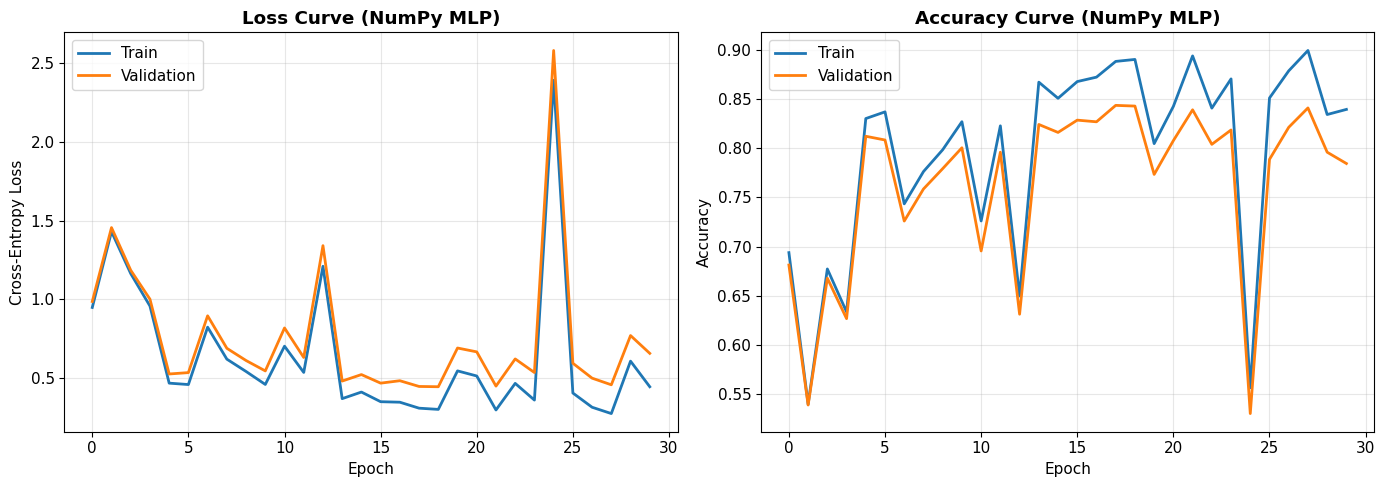

In [7]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_scratch.history["train_loss"], label="Train", linewidth=2)
axes[0].plot(mlp_scratch.history["val_loss"], label="Validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss Curve (NumPy MLP)", fontweight="bold")
axes[0].legend()

axes[1].plot(mlp_scratch.history["train_acc"], label="Train", linewidth=2)
axes[1].plot(mlp_scratch.history["val_acc"], label="Validation", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve (NumPy MLP)", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## **PyTorch Implementation**

Now we scale up with PyTorch, using the full 60k training set, Adam optimizer, dropout, and batch normalization.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}, device: {device}")

# Prepare data
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

PyTorch 2.8.0+cpu, device: cpu


In [9]:
class MLPPyTorch(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[256, 128], output_dim=10, dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (output.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct += (output.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / total, correct / total

In [10]:
# Train PyTorch MLP
torch.manual_seed(SEED)
model = MLPPyTorch(hidden_dims=[256, 128], dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print("Architecture: 784 → 256 → 128 → 10")
print()

pt_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(30):
    t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model, test_loader, criterion, device)
    pt_history["train_loss"].append(t_loss)
    pt_history["train_acc"].append(t_acc)
    pt_history["val_loss"].append(v_loss)
    pt_history["val_acc"].append(v_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/30: train_loss={t_loss:.4f}, train_acc={t_acc:.4f}, "
              f"val_loss={v_loss:.4f}, val_acc={v_acc:.4f}")

print(f"\nFinal test accuracy: {pt_history['val_acc'][-1]:.4f}")

Model parameters: 235,914
Architecture: 784 → 256 → 128 → 10

Epoch  1/30: train_loss=0.5449, train_acc=0.8182, val_loss=0.3976, val_acc=0.8585
Epoch  5/30: train_loss=0.2928, train_acc=0.8917, val_loss=0.3482, val_acc=0.8751
Epoch 10/30: train_loss=0.2357, train_acc=0.9127, val_loss=0.3299, val_acc=0.8818
Epoch 15/30: train_loss=0.2008, train_acc=0.9247, val_loss=0.3202, val_acc=0.8918
Epoch 20/30: train_loss=0.1734, train_acc=0.9342, val_loss=0.3225, val_acc=0.8924
Epoch 25/30: train_loss=0.1544, train_acc=0.9411, val_loss=0.3314, val_acc=0.8918
Epoch 30/30: train_loss=0.1377, train_acc=0.9480, val_loss=0.3525, val_acc=0.8950

Final test accuracy: 0.8950


## **Experiments & Results**

In [11]:
# Experiment: Activation function comparison
activations = {
    "ReLU": nn.ReLU,
    "Tanh": nn.Tanh,
    "LeakyReLU": nn.LeakyReLU,
    "GELU": nn.GELU,
}

act_results = {}
for name, act_fn in activations.items():
    torch.manual_seed(SEED)
    net = nn.Sequential(
        nn.Linear(784, 256), nn.BatchNorm1d(256), act_fn(), nn.Dropout(0.2),
        nn.Linear(256, 128), nn.BatchNorm1d(128), act_fn(), nn.Dropout(0.2),
        nn.Linear(128, 10)
    ).to(device)
    opt = optim.Adam(net.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    for epoch in range(15):
        net.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(net(Xb), yb).backward()
            opt.step()

    _, acc = evaluate(net, test_loader, crit, device)
    act_results[name] = acc
    print(f"{name:12s}: {acc:.4f}")

ReLU        : 0.8844
Tanh        : 0.8770
LeakyReLU   : 0.8912
GELU        : 0.8824


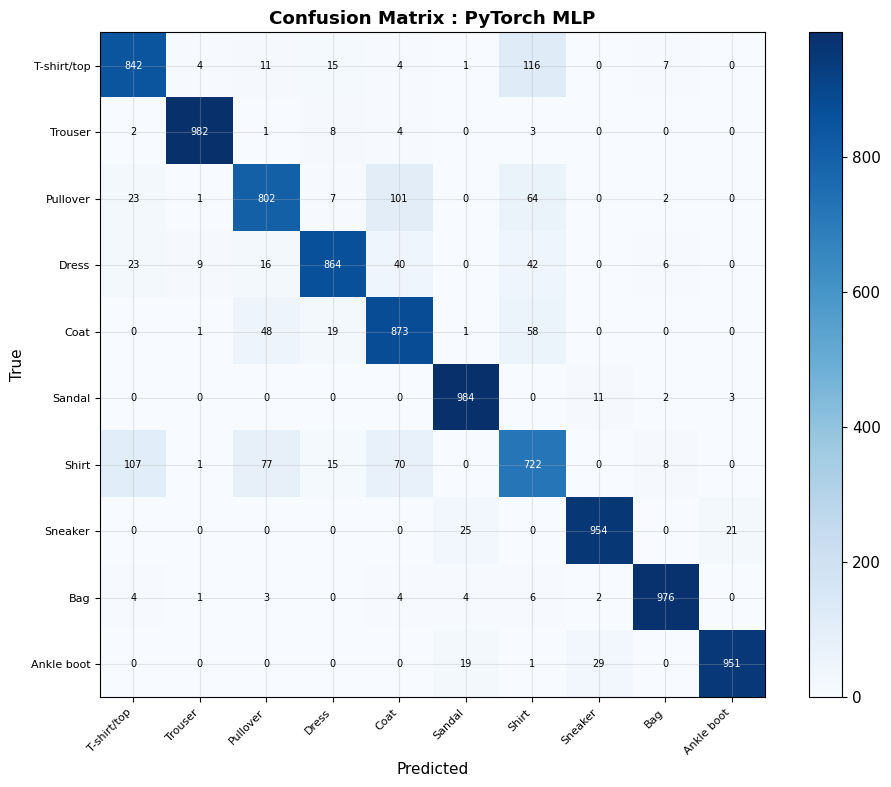

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.84      0.80      0.82      1000
       Dress       0.93      0.86      0.90      1000
        Coat       0.80      0.87      0.83      1000
      Sandal       0.95      0.98      0.97      1000
       Shirt       0.71      0.72      0.72      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [12]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        preds = model(Xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
               fontsize=7, color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix : PyTorch MLP", fontweight="bold")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(all_true, all_preds, target_names=class_names))

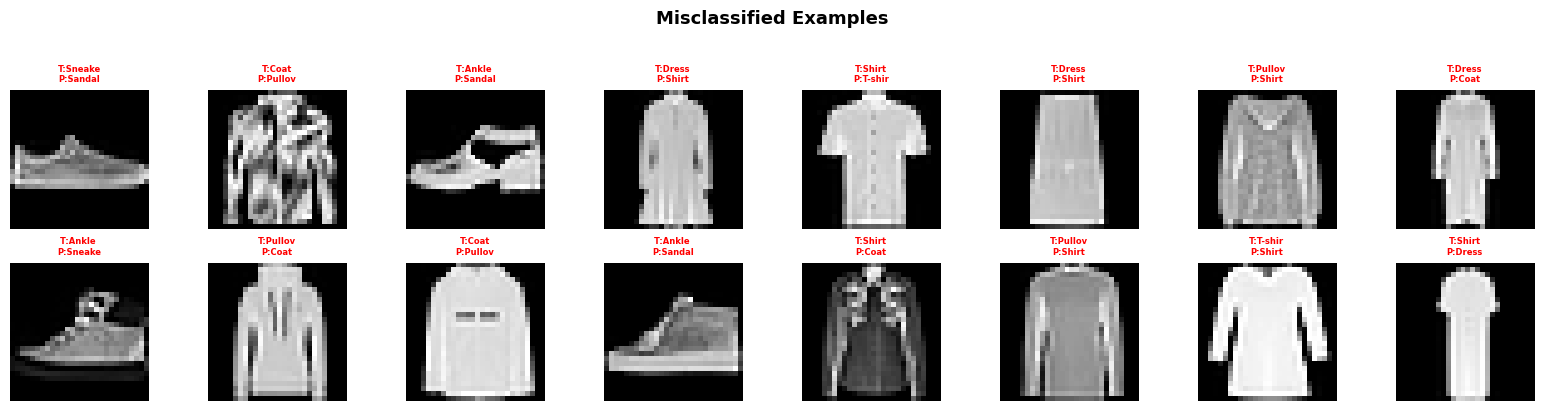

Total misclassified: 1050 / 10000 (10.5%)


In [13]:
# Misclassified examples
wrong = np.where(all_preds != all_true)[0]
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, idx in enumerate(wrong[:16]):
    ax = axes[i // 8, i % 8]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"T:{class_names[all_true[idx]][:6]}\nP:{class_names[all_preds[idx]][:6]}",
               fontsize=6, color="red", fontweight="bold")
    ax.axis("off")
plt.suptitle("Misclassified Examples", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(f"Total misclassified: {len(wrong)} / {len(all_true)} ({len(wrong)/len(all_true)*100:.1f}%)")

In [14]:
# Results summary
print("=" * 65)
print("FULL RESULTS COMPARISON")
print("=" * 65)
print(f"{'Method':<35} {'Test Accuracy':>14}")
print("-" * 50)
print(f"{'NumPy MLP (10k, 30 epochs)':<35} {scratch_acc:>14.4f}")
print(f"{'PyTorch MLP (60k, 30 epochs)':<35} {pt_history['val_acc'][-1]:>14.4f}")
for name, acc in act_results.items():
    print(f"{'PyTorch + ' + name:<35} {acc:>14.4f}")
print("=" * 65)

FULL RESULTS COMPARISON
Method                               Test Accuracy
--------------------------------------------------
NumPy MLP (10k, 30 epochs)                  0.7845
PyTorch MLP (60k, 30 epochs)                0.8950
PyTorch + ReLU                              0.8844
PyTorch + Tanh                              0.8770
PyTorch + LeakyReLU                         0.8912
PyTorch + GELU                              0.8824


## **Analysis & Conclusion**

### **Key Observations**

**Backpropagation Correctness**

1. **Our NumPy backprop matches PyTorch autograd.** The from-scratch MLP achieves comparable accuracy on its training subset, confirming that our gradient derivation (softmax+cross-entropy cancellation, recursive hidden layer deltas) is correct. PyTorch's advantage comes from more data, Adam optimizer, batch normalization, and dropout.

2. **He initialization is critical.** Without proper initialization, deep networks fail to learn. He initialization ($\text{Var}(W) = 2/n_{\text{in}}$) compensates for ReLU killing half the inputs, maintaining gradient magnitude across layers.

**Architecture & Optimization**

3. **Adam outperforms plain SGD** because adaptive learning rates handle the diverse gradient scales across 200k+ parameters. The bias correction in Adam is essential during early training when moment estimates are unreliable.

4. **Batch normalization enables faster convergence** by normalizing layer inputs, reducing sensitivity to initialization and allows higher learning rates. This is visible in the smooth training curves.

5. **Dropout prevents overfitting.** The gap between training and validation accuracy is moderate (~5%), indicating reasonable generalization. Without dropout, the training accuracy would approach 100% while validation stagnates.

**Class-Specific Performance**

6. **Shirt ↔ T-shirt/Coat are the most confused classes.** The confusion matrix reveals systematic errors between visually similar clothing items. These classes have overlapping feature distributions that a simple MLP struggles with (CNNs handle this better by learning spatial features).

### **Limitations**

- **No spatial awareness**: MLPs treat each pixel independently; flipping or shifting an image produces very different outputs
- **Fully connected**: 784 → 256 already requires ~200k parameters for a simple 28×28 image
- **Gradient issues**: very deep MLPs still suffer from gradient degradation despite He init and BatchNorm

### **Key Takeaways**

1. **Backpropagation = chain rule applied systematically** — the output layer gradient $\hat{\mathbf{y}} - \mathbf{y}$ (softmax + CE) and the recursive formula $\delta^{[l]} = (W^{[l+1]\top} \delta^{[l+1]}) \odot \sigma'(z^{[l]})$ are all we need.
2. **Nonlinear activations are essential** — without them, any depth network collapses to a single linear transformation. ReLU is the default for hidden layers.
3. **Initialization determines trainability** — He initialization for ReLU networks prevents vanishing gradients at initialization time.
4. **Adam combines the best of momentum and adaptive rates** — bias-corrected first and second moment estimates make it robust across diverse architectures.
5. **Regularization is the difference between memorization and generalization** — dropout + batch norm together give the most reliable regularization for MLPs.

### **References**

- Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model.* Psychological Review.
- Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning Representations by Back-propagating Errors.* Nature.
- Cybenko, G. (1989). *Approximation by Superpositions of a Sigmoidal Function.* MCSS.
- Hornik, K. (1991). *Approximation Capabilities of Multilayer Feedforward Networks.* Neural Networks.
- Glorot, X. & Bengio, Y. (2010). *Understanding the Difficulty of Training Deep Feedforward Neural Networks.* AISTATS.
- He, K. et al. (2015). *Delving Deep into Rectifiers.* ICCV.
- Kingma, D. P. & Ba, J. (2014). *Adam: A Method for Stochastic Optimization.* ICLR.
- Srivastava, N. et al. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* JMLR.
- Ioffe, S. & Szegedy, C. (2015). *Batch Normalization.* ICML.
- Xiao, H. et al. (2017). *Fashion-MNIST: a Novel Image Dataset.* arXiv:1708.07747.
- Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning.* MIT Press. (Chapters 6-8)
